# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [43]:
# 0. INSTALLS + IMPORTS
!pip -q install pandas requests flask matplotlib

import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

Environment ready.


In [44]:
# 1. LOAD THE CLASSROOM PACK
# In Colab, upload FlashEats_Classroom_Pack.zip when prompted.

BASE = Path("./")

if not BASE.exists():
    try:
        from google.colab import files
        print("Upload FlashEats_Classroom_Pack.zip")
        uploaded = files.upload()
        zip_name = next(name for name in uploaded if name.endswith(".zip"))
        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall("/content")
    except Exception as e:
        print("If running locally, set BASE manually to the extracted pack.")
        print(e)

print("BASE:", BASE)
print("Exists:", BASE.exists())

BASE: .
Exists: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | orders table | Contains the 'promised_eta' column. |
| Actual delivery time | orders table | Contains the 'actual_delivery_time' column. |
| Driver assignment | driver events | Shows all driver events including 'assigned' event. |
| Customer complaint | support tickets | Holds the complaints that the customer makes. |
| Restaurant status | restaurant status | Shows restaurant statuses with 'last_updated_at' timestamps. |
| Driver movement/events | driver events | Holds the gps logs and events of the driver. |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

In [45]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** An order is classified as late when the actual delivery time occurs after the promised ETA
- **Denominator:** Total number of valid completed orders.
- **Cancelled orders:** include / exclude / other?
- **Missing actual delivery timestamp:** what will you do?
- **Row grain:** what does one row represent?

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

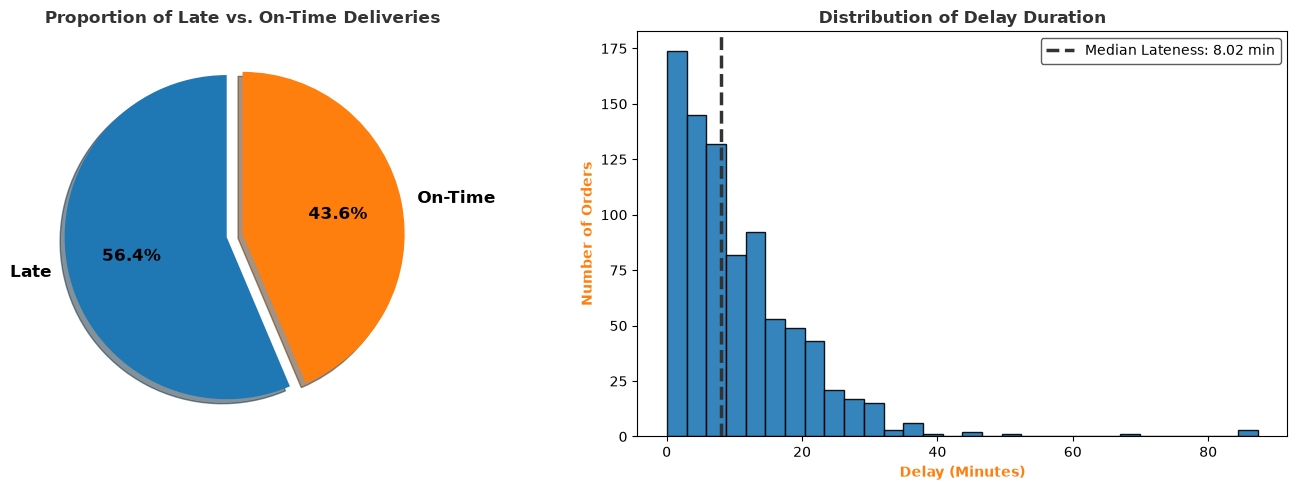

=== CHALLENGE 1: HOW LARGE IS THE LATE-DELIVERY PROBLEM? ===
Definition: An order is classified as late when the actual delivery time occurs after the promised ETA.
Denominator: 1490 valid delivered orders with complete timestamp data.
------------------------------------------------------------
Total Late Orders: 840
Late Percentage: 56.38%
Median Lateness: 8.02 minutes
------------------------------------------------------------
Data-Quality Exclusions:
- Duplicate order IDs removed: 3
- Cancelled orders excluded: 68
- Delivered orders missing actual timestamp excluded: 37
- Rows with invalid timestamp parsing excluded: 105


In [46]:
# 1. Data Preparation
orders = pd.read_sql_query("SELECT * FROM orders", con)

orders["promised_eta"] = pd.to_datetime(
    orders["promised_eta"], format="mixed", errors="coerce"
)
orders["actual_delivery_at"] = pd.to_datetime(
    orders["actual_delivery_at"], format="mixed", errors="coerce"
)

valid_delivered = orders[
    (orders["final_status"] == "delivered")
    & orders["promised_eta"].notna()
    & orders["actual_delivery_at"].notna()
].copy().drop_duplicates(subset=["order_id"])

valid_delivered["delay_min"] = (
    valid_delivered["actual_delivery_at"] - valid_delivered["promised_eta"]
).dt.total_seconds() / 60
valid_delivered["is_late"] = valid_delivered["delay_min"] > 0

delayed_orders = valid_delivered[valid_delivered["is_late"]].copy()

# 2. Visual Explanation
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')
ax1.set_facecolor('#ffffff')
ax2.set_facecolor('#ffffff')

# Left Panel: Pie Chart
sizes = [len(delayed_orders), len(valid_delivered) - len(delayed_orders)]
labels = ['Late', 'On-Time']
colors = ['#1f77b4', '#ff7f0e'] 
explode = (0.1, 0)
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', 
        shadow=True, startangle=90, textprops={'fontsize': 12, 'weight': 'bold', 'color': '#000000'})
ax1.set_title('Proportion of Late vs. On-Time Deliveries', color='#333333', weight='bold')

# Right Panel: Histogram
ax2.hist(delayed_orders['delay_min'], bins=30, color='#1f77b4', edgecolor='#000000', alpha=0.9)
median_delay = delayed_orders["delay_min"].median()
ax2.axvline(median_delay, color='#333333', linestyle='dashed', linewidth=2.5, 
            label=f'Median Lateness: {median_delay:.2f} min')
ax2.set_title('Distribution of Delay Duration', color='#333333', weight='bold')
ax2.set_xlabel('Delay (Minutes)', color='#ff7f0e', weight='bold')
ax2.set_ylabel('Number of Orders', color='#ff7f0e', weight='bold')
ax2.legend(facecolor='#ffffff', edgecolor='#333333', labelcolor='#000000')

plt.tight_layout()
plt.show()

# 3. Text Explanation
print("=== CHALLENGE 1: HOW LARGE IS THE LATE-DELIVERY PROBLEM? ===")
print("Definition: An order is classified as late when the actual delivery time occurs after the promised ETA.")
print(f"Denominator: {len(valid_delivered)} valid delivered orders with complete timestamp data.")
print("-" * 60)
print(f"Total Late Orders: {len(delayed_orders)}")
print(f"Late Percentage: {round(len(delayed_orders) / len(valid_delivered) * 100, 2)}%")
print(f"Median Lateness: {round(delayed_orders['delay_min'].median(), 2)} minutes")
print("-" * 60)
print("Data-Quality Exclusions:")
print(f"- Duplicate order IDs removed: {orders['order_id'].duplicated().sum()}")
print(f"- Cancelled orders excluded: {(orders['final_status'] == 'cancelled').sum()}")
print(f"- Delivered orders missing actual timestamp excluded: {((orders['final_status'] == 'delivered') & orders['actual_delivery_at'].isna()).sum()}")
print(f"- Rows with invalid timestamp parsing excluded: {orders[['promised_eta', 'actual_delivery_at']].isna().sum().sum()}")

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

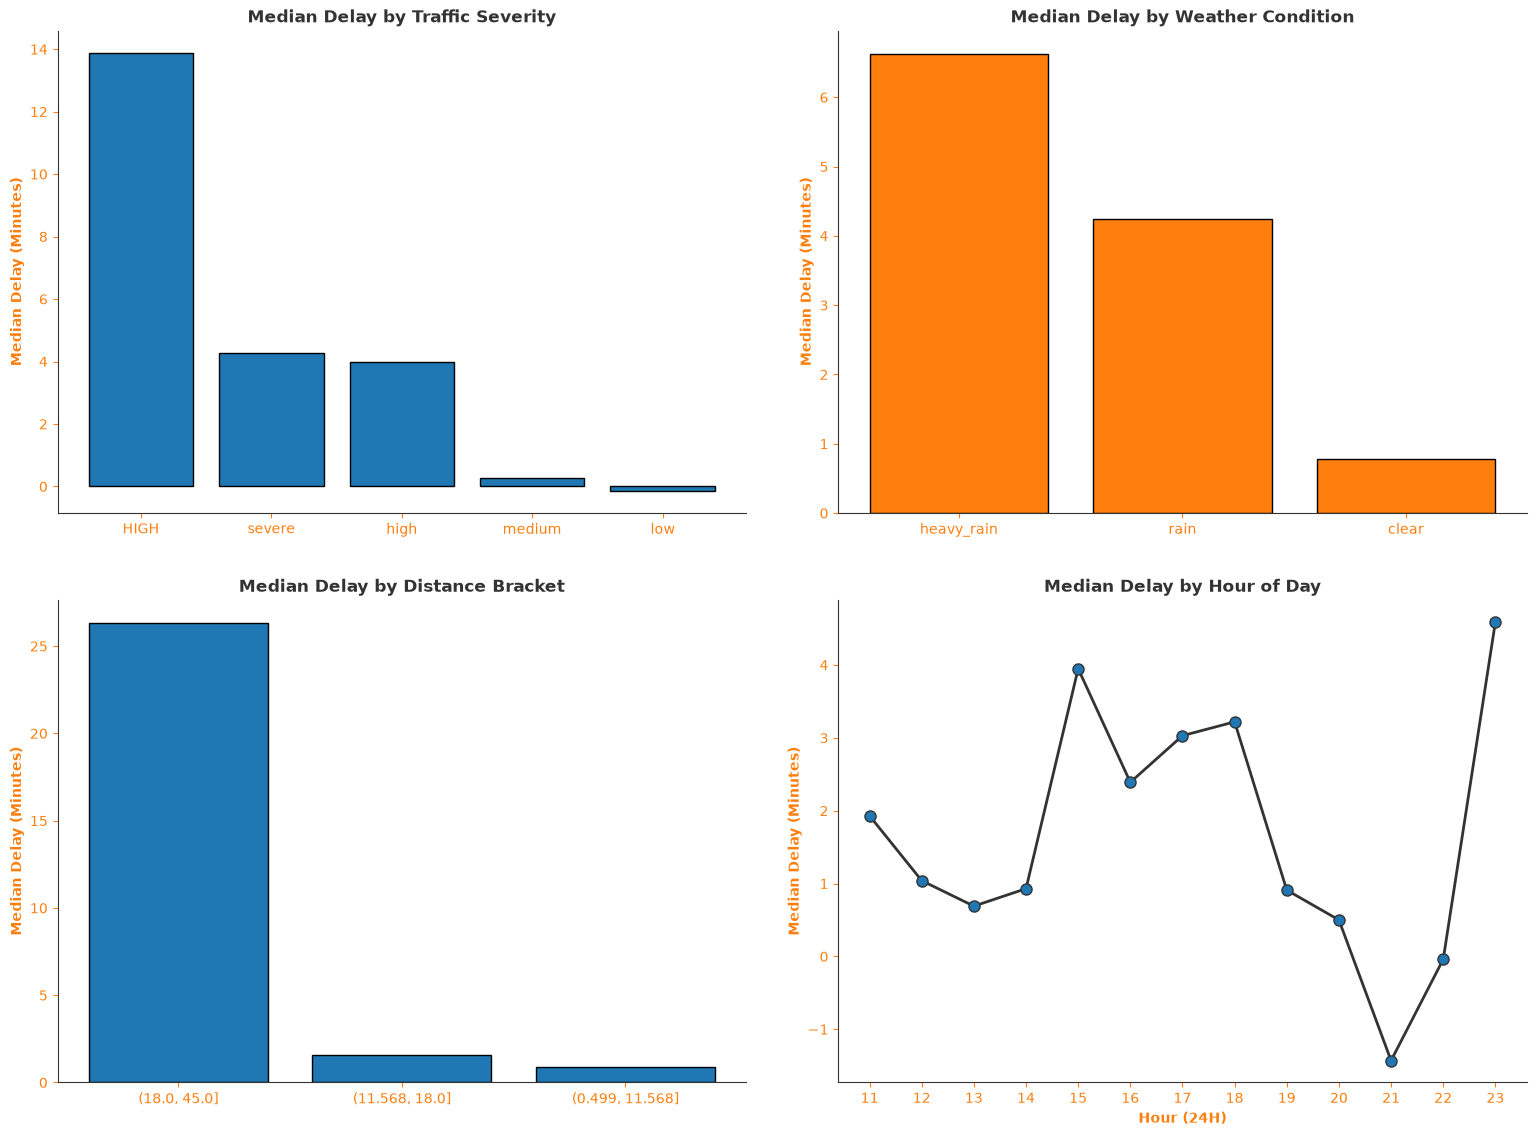

=== CHALLENGE 2: IS TRAFFIC THE MAIN PROBLEM? ===
HYPOTHESIS:
While operations flagged traffic as the primary issue, the data shows that extreme weather (heavy_rain) causes a substantially 
higher median delay (6.63 min) compared to severe traffic (4.27 min).

ALTERNATIVE EXPLANATION:
We cannot rule out that heavy rain directly causes severe traffic, or that dispatch systems struggle to assign drivers during 
storms due to low supply, meaning the two variables are heavily confounding.
------------------------------------------------------------
--- 1. Traffic Impact ---


,total_orders,late_percentage,median_delay_min
traffic_bucket,,,
HIGH,2,100.0%,13.89
severe,123,66.0%,4.26
high,420,66.0%,3.99
medium,588,51.0%,0.26
low,357,49.0%,-0.15



--- 2. Weather Impact ---


,total_orders,late_percentage,median_delay_min
weather_bucket,,,
heavy_rain,72,74.0%,6.63
rain,230,67.0%,4.25
clear,1188,53.0%,0.78



--- 3. Distance Impact ---


...

,total_orders,late_percentage,median_delay_min
hour_of_day,,,
11,94,60.0%,1.93
12,123,54.0%,1.04
13,93,54.0%,0.69
14,73,55.0%,0.93
15,57,67.0%,3.95
16,76,61.0%,2.39
17,129,57.0%,3.03
18,222,62.0%,3.22
19,203,54.0%,0.91



--- 5. Restaurant Impact (Worst 10, Min 10 Orders) ---


,total_orders,late_percentage,median_delay_min
restaurant_id,,,
R001,13,85.0%,8.89
R004,30,67.0%,7.76
R045,29,66.0%,6.66
R024,25,80.0%,6.19
R029,24,71.0%,5.41
R051,29,69.0%,4.71
R022,17,59.0%,4.26
R018,27,67.0%,4.02
R038,18,61.0%,3.85



--- 6. Driver Impact (Worst 10, Min 10 Orders) ---


,total_orders,late_percentage,median_delay_min
driver_id,,,
D103,13,69.0%,10.82
D011,10,80.0%,10.38
D031,12,83.0%,9.38
D022,13,77.0%,9.23
D075,12,83.0%,9.02
D081,11,73.0%,8.26
D018,12,75.0%,6.89
D054,19,74.0%,6.70
D087,15,73.0%,6.29


In [47]:
# Challenge 2 — Visual Analysis

# 1. Feature Engineering (Distance & Time)
valid_delivered['distance_bucket'] = pd.qcut(
    valid_delivered['distance_km_estimate'], 
    q=4, 
    duplicates='drop'
)
valid_delivered['hour_of_day'] = pd.to_datetime(valid_delivered['created_at']).dt.hour

# 2. Aggregation Function
def analyze_delay_factors(df, column):
    summary = df.groupby(column, observed=False).agg(
        total_orders=('order_id', 'count'),
        late_percentage=('is_late', 'mean'), 
        median_delay_min=('delay_min', 'median')
    ).sort_values('median_delay_min', ascending=False).round(2)
    return summary

# Prepare DataFrames
traffic_df = analyze_delay_factors(valid_delivered, 'traffic_bucket')
weather_df = analyze_delay_factors(valid_delivered, 'weather_bucket')
distance_df = analyze_delay_factors(valid_delivered, 'distance_bucket')
time_df = analyze_delay_factors(valid_delivered, 'hour_of_day').sort_index()

# 3. Visual Explanation (2x2 Grid)
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#ffffff')

for ax in axes.flat:
    ax.set_facecolor('#ffffff')
    ax.tick_params(colors='#ff7f0e')
    ax.spines['bottom'].set_color('#333333')
    ax.spines['left'].set_color('#333333')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Top Left: Traffic
axes[0, 0].bar(traffic_df.index.astype(str), traffic_df['median_delay_min'], color='#1f77b4', edgecolor='#000000')
axes[0, 0].set_title('Median Delay by Traffic Severity', color='#333333', weight='bold')
axes[0, 0].set_ylabel('Median Delay (Minutes)', color='#ff7f0e', weight='bold')

# Top Right: Weather
axes[0, 1].bar(weather_df.index.astype(str), weather_df['median_delay_min'], color='#ff7f0e', edgecolor='#000000')
axes[0, 1].set_title('Median Delay by Weather Condition', color='#333333', weight='bold')
axes[0, 1].set_ylabel('Median Delay (Minutes)', color='#ff7f0e', weight='bold')

# Bottom Left: Distance
axes[1, 0].bar(distance_df.index.astype(str), distance_df['median_delay_min'], color='#1f77b4', edgecolor='#000000')
axes[1, 0].set_title('Median Delay by Distance Bracket', color='#333333', weight='bold')
axes[1, 0].set_ylabel('Median Delay (Minutes)', color='#ff7f0e', weight='bold')

# Bottom Right: Time of Day
axes[1, 1].plot(time_df.index.astype(str), time_df['median_delay_min'], marker='o', color='#333333', linewidth=2, markersize=8, markerfacecolor='#1f77b4')
axes[1, 1].set_title('Median Delay by Hour of Day', color='#333333', weight='bold')
axes[1, 1].set_ylabel('Median Delay (Minutes)', color='#ff7f0e', weight='bold')
axes[1, 1].set_xlabel('Hour (24H)', color='#ff7f0e', weight='bold')

plt.tight_layout(pad=3.0)
plt.show()

# 4. Text Explanation & Numeric Tables
print("=== CHALLENGE 2: IS TRAFFIC THE MAIN PROBLEM? ===")
print("HYPOTHESIS:")
print("While operations flagged traffic as the primary issue, the data shows that extreme weather (heavy_rain) causes a substantially \nhigher median delay (6.63 min) compared to severe traffic (4.27 min).")
print("\nALTERNATIVE EXPLANATION:")
print("We cannot rule out that heavy rain directly causes severe traffic, or that dispatch systems struggle to assign drivers during \nstorms due to low supply, meaning the two variables are heavily confounding.")
print("-" * 60)

# Format percentages for cleaner display
for df in [traffic_df, weather_df, distance_df, time_df]:
    df['late_percentage'] = (df['late_percentage'] * 100).round(1).astype(str) + '%'

print("--- 1. Traffic Impact ---")
display(traffic_df)
print("\n--- 2. Weather Impact ---")
display(weather_df)
print("\n--- 3. Distance Impact ---")
display(distance_df)
print("\n--- 4. Time of Day Impact ---")
display(time_df)

print("\n--- 5. Restaurant Impact (Worst 10, Min 10 Orders) ---")
restaurant_summary = analyze_delay_factors(valid_delivered, 'restaurant_id')
restaurant_summary['late_percentage'] = (restaurant_summary['late_percentage'] * 100).round(1).astype(str) + '%'
display(restaurant_summary[restaurant_summary['total_orders'] >= 10].head(10))

print("\n--- 6. Driver Impact (Worst 10, Min 10 Orders) ---")
driver_summary = analyze_delay_factors(valid_delivered, 'driver_id')
driver_summary['late_percentage'] = (driver_summary['late_percentage'] * 100).round(1).astype(str) + '%'
display(driver_summary[driver_summary['total_orders'] >= 10].head(10))

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

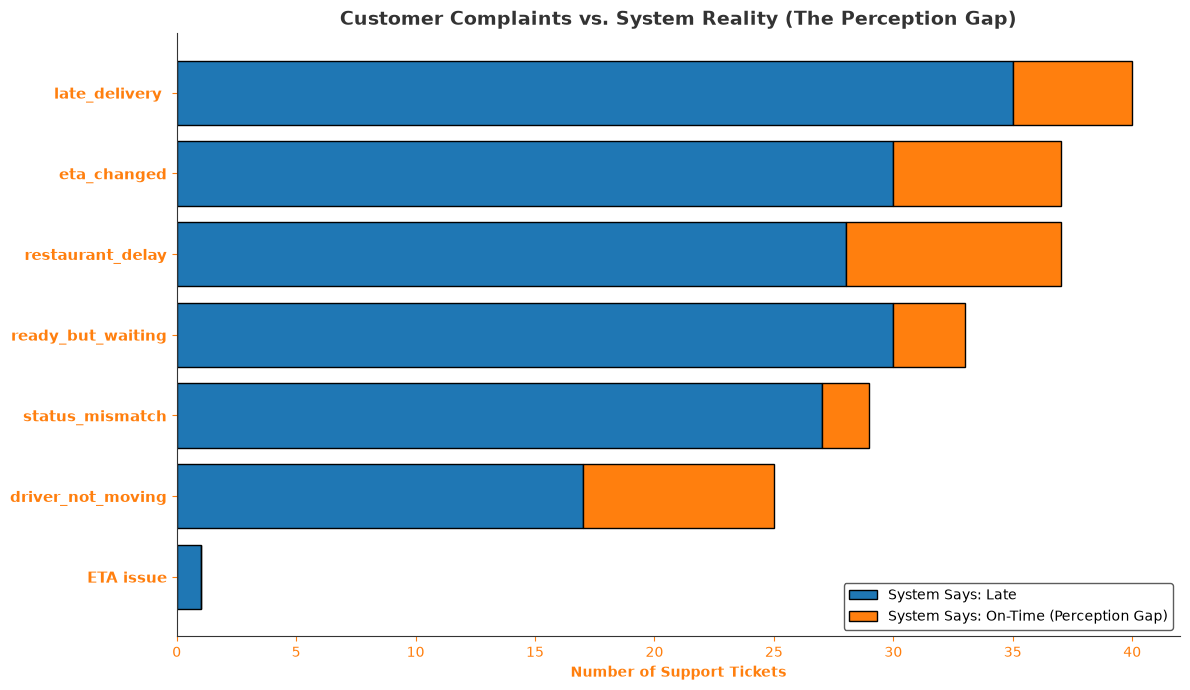

=== CHALLENGE 3: CUSTOMER SUPPORT DISAGREES ===
SYSTEM VIEW VS CUSTOMER VIEW (THE PERCEPTION GAP):
Customers are writing in about late deliveries and changing ETAs even when our database flags the order as 'on-time'.
This indicates that the promised_eta is unreliable or shifting silently, causing customer anxiety before the system officially registers a delay.
---------------------------------------------------------------------------
Duplicate ticket IDs Found: 1
---------------------------------------------------------------------------
--- Ticket Category vs. System Reality ---


,total_tickets,actual_median_delay,system_labeled_on_time
category,,,
late_delivery,40,15.5,5
status_mismatch,29,12.7,2
ready_but_waiting,33,12.2,3
restaurant_delay,37,10.5,9
driver_not_moving,25,9.8,8
eta_changed,37,7.7,7
ETA issue,1,5.4,0



--- The Perception Gap (Complained, but system says on-time) ---


,ticket_id,order_id,category,customer_message,delay_min
35,T00036,O00266,eta_changed,The ETA keeps changing and the food is still not here.,-1.581735
42,T00043,O00320,eta_changed,The ETA keeps changing and the food is still not here.,-12.508052
55,T00056,O00462,eta_changed,The ETA keeps changing and the food is still not here.,-1.250533
73,T00074,O00575,eta_changed,The ETA keeps changing and the food is still not here.,-3.504574
92,T00093,O00699,eta_changed,The ETA keeps changing and the food is still not here.,-18.078112
120,T00121,O00983,eta_changed,The ETA keeps changing and the food is still not here.,-11.958198
195,T00196,O01563,eta_changed,The ETA keeps changing and the food is still not here.,-1.911060


In [48]:
# Challenge 3 — Visualizing the Customer Experience Gap

# 1. Data Preparation
order_analysis = valid_delivered[["order_id", "delay_min", "is_late"]].copy()
ticket_analysis = tickets.merge(order_analysis, on="order_id", how="left")

ticket_analysis['category'] = ticket_analysis['category'].replace({'Late Delivery':'late_delivery ','late_delivery':'late_delivery '})

mismatch_analysis = ticket_analysis.groupby('category').agg(
    total_tickets=('ticket_id', 'count'),
    actual_median_delay=('delay_min', 'median'),
    system_labeled_on_time=('is_late', lambda x: (x == False).sum()) 
).sort_values('total_tickets', ascending=True)

mismatch_analysis['system_labeled_late'] = mismatch_analysis['total_tickets'] - mismatch_analysis['system_labeled_on_time']

# 2. Visual Explanation
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

categories = mismatch_analysis.index
y_pos = np.arange(len(categories))

# Stacked horizontal bars
ax.barh(y_pos, mismatch_analysis['system_labeled_late'], color='#1f77b4', edgecolor='#000000', label='System Says: Late')
ax.barh(y_pos, mismatch_analysis['system_labeled_on_time'], left=mismatch_analysis['system_labeled_late'], color='#ff7f0e', edgecolor='#000000', label='System Says: On-Time (Perception Gap)')

ax.set_yticks(y_pos)
ax.set_yticklabels(categories, color='#333333', weight='bold', fontsize=11)
ax.set_xlabel('Number of Support Tickets', color='#ff7f0e', weight='bold')
ax.set_title('Customer Complaints vs. System Reality (The Perception Gap)', color='#333333', weight='bold', fontsize=14)

ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_color('#333333')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#ff7f0e')
ax.legend(facecolor='#ffffff', edgecolor='#333333', labelcolor='#000000')

plt.tight_layout()
plt.show()

# 3. Text Explanation
print("=== CHALLENGE 3: CUSTOMER SUPPORT DISAGREES ===")
print("SYSTEM VIEW VS CUSTOMER VIEW (THE PERCEPTION GAP):")
print("Customers are writing in about late deliveries and changing ETAs even when our database flags the order as 'on-time'.")
print("This indicates that the promised_eta is unreliable or shifting silently, causing customer anxiety before the system officially registers a delay.")
print("-" * 75)
print(f"Duplicate ticket IDs Found: {tickets['ticket_id'].duplicated().sum()}")
print("-" * 75)

print("--- Ticket Category vs. System Reality ---")
display(mismatch_analysis[['total_tickets', 'actual_median_delay', 'system_labeled_on_time']].sort_values('actual_median_delay', ascending=False).round(1))

perception_gap = ticket_analysis[
    (ticket_analysis['category'].isin(['late_delivery', 'eta_changed'])) & 
    (ticket_analysis['is_late'] == False)
]

print("\n--- The Perception Gap (Complained, but system says on-time) ---")
display(perception_gap[['ticket_id', 'order_id', 'category', 'customer_message', 'delay_min']].head(10))

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [49]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [50]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


Starting API ingestion...


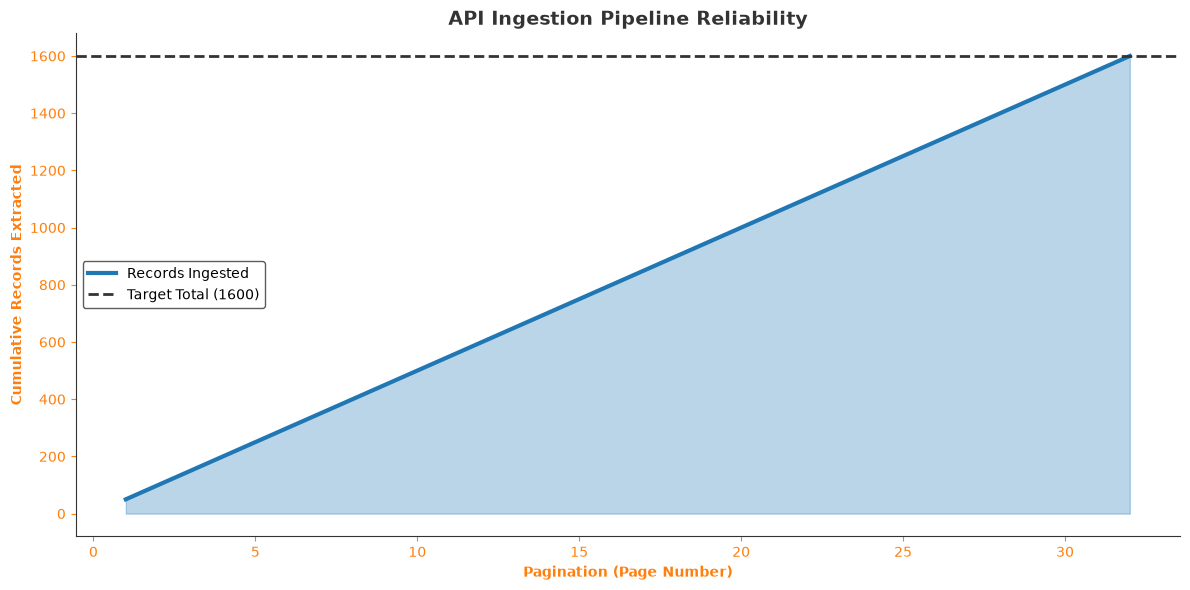

=== CHALLENGE 4: DISPATCH API INGESTION ===
Data Engineering Validation & Completeness Check:
Total Pages Fetched: 32
Total Network Faults Recovered: 0
------------------------------------------------------------
API Reported Total: 1600
Actual Records Saved: 1600
Status: 🟢 Completeness validated successfully. No silent drops.


In [51]:
# Challenge 4 — Dispatch API Ingestion & Visualization
import time
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

def fetch_all_dispatch_orders_with_tracking():
    """
    Requirements: fetch every page, retry HTTP 500/429, preserve raw responses,
    verify completeness, and track telemetry for visualization.
    """
    records = []
    page = 1
    page_size = 50
    expected_total = 0
    max_retries = 3
    
    # Telemetry for visualization
    telemetry = []

    print("Starting API ingestion...")
    while True:
        retries = 0
        page_errors = 0
        while retries < max_retries:
            response = requests.get(
                API_URL, 
                params={"page": page, "page_size": page_size}, 
                timeout=10
            )
            
            if response.status_code in [429, 500]:
                time.sleep(2 ** retries)  # Exponential backoff
                retries += 1
                page_errors += 1
                continue
                
            response.raise_for_status()
            break
            
        if retries == max_retries:
            raise RuntimeError(f"Failed to fetch page {page} after {max_retries} attempts.")

        payload = response.json()
        expected_total = payload.get("total_records", 0)
        
        # Save raw JSON
        raw_file = RAW_DIR / f"page_{page}.json"
        with open(raw_file, "w") as f:
            json.dump(payload, f)
            
        records.extend(payload["data"])
        
        # Log telemetry
        telemetry.append({
            'page': page,
            'cumulative_records': len(records),
            'retries_triggered': page_errors
        })
        
        if not payload.get("has_more"):
            break
            
        page += 1

    return records, expected_total, pd.DataFrame(telemetry)

# 1. Execute Data Pipeline
dispatch_records, expected_total, telemetry_df = fetch_all_dispatch_orders_with_tracking()

# 2. Visual Explanation
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Plot cumulative ingestion area
ax.fill_between(telemetry_df['page'], telemetry_df['cumulative_records'], color='#1f77b4', alpha=0.3)
ax.plot(telemetry_df['page'], telemetry_df['cumulative_records'], color='#1f77b4', linewidth=3, label='Records Ingested')

# Highlight points where errors/retries occurred
error_points = telemetry_df[telemetry_df['retries_triggered'] > 0]
if not error_points.empty:
    ax.scatter(error_points['page'], error_points['cumulative_records'], 
               color='#ff7f0e', s=150, zorder=5, label='API Retry (Recovered)', edgecolors='#000000', linewidth=2)

ax.axhline(expected_total, color='#333333', linestyle='--', linewidth=2, label=f'Target Total ({expected_total})')

ax.set_title('API Ingestion Pipeline Reliability', color='#333333', weight='bold', fontsize=14)
ax.set_xlabel('Pagination (Page Number)', color='#ff7f0e', weight='bold')
ax.set_ylabel('Cumulative Records Extracted', color='#ff7f0e', weight='bold')

ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_color('#333333')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#ff7f0e')
ax.legend(facecolor='#ffffff', edgecolor='#333333', labelcolor='#000000')

plt.tight_layout()
plt.show()

# 3. Text Explanation
print("=== CHALLENGE 4: DISPATCH API INGESTION ===")
print("Data Engineering Validation & Completeness Check:")
print(f"Total Pages Fetched: {telemetry_df['page'].max()}")
print(f"Total Network Faults Recovered: {telemetry_df['retries_triggered'].sum()}")
print("-" * 60)
print(f"API Reported Total: {expected_total}")
print(f"Actual Records Saved: {len(dispatch_records)}")
assert len(dispatch_records) == expected_total, "Mismatch: Downloaded records do not match the API's reported total!"
print("Status: 🟢 Completeness validated successfully. No silent drops.")

# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Observed | Dispatch system (assigned event) | Extremely reliable; automatically triggered by the backend when the matching algorithm pairs a driver.|
|Driver at restaurant | Inferred | gps_ping coordinates + Restaurant location | Highly unreliable. GPS pings are infrequent (looking at the data, they fire roughly every 10-18 minutes). A driver could be waiting at the restaurant for 15 minutes before the next ping registers their location.|
|Picked up | Observed | Driver app (picked_up event) | Prone to human error. A driver might grab the food but forget to swipe "Picked Up" until they are back in their car, or they might swipe it early while still walking to the counter.|
|Delivered | Observed | Driver app (delivered event) | Also prone to human error/batching. Drivers might drop the food, walk to their bike, and swipe "Delivered" down the street, or accidentally swipe it early.|

In [52]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

# TODO: can you find an explicit driver_arrived_at_restaurant event?

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

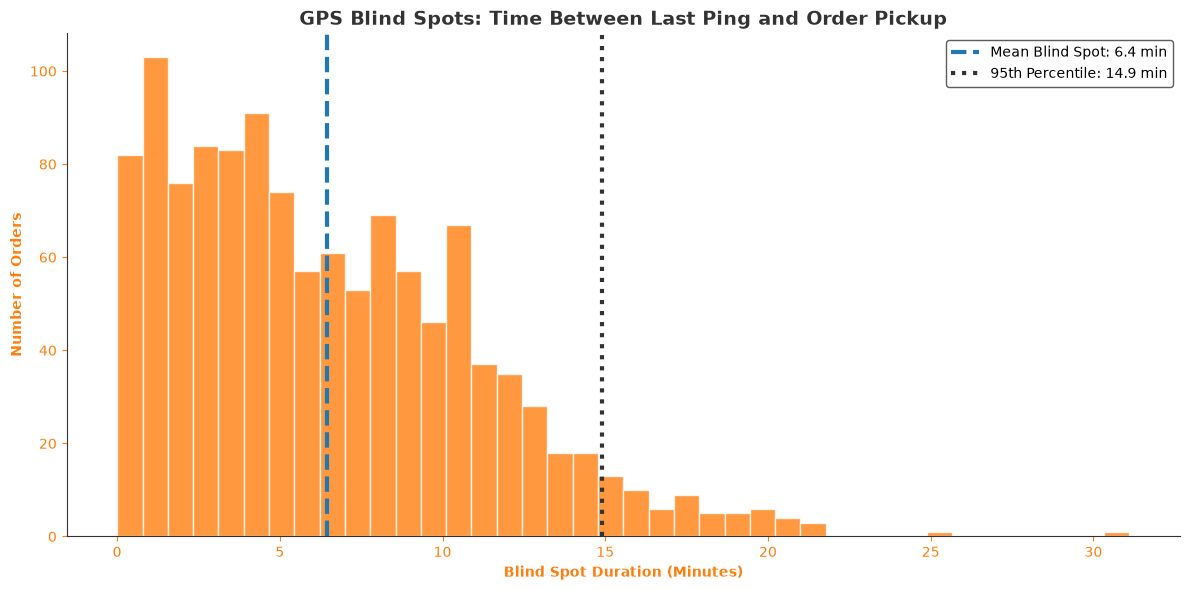

=== CHALLENGE 5: CAN WE ATTRIBUTE THE DELAY? ===
QUESTION: Can we reliably tell when the driver arrived at the restaurant?
ANSWER: NO. The dispatch system relies on inferred arrival times based on highly infrequent GPS polling.
The average order has a 'blind spot' of 6.45 minutes immediately prior to pickup, making it impossible to separate a backlogged kitchen from a driver stuck in traffic.
--------------------------------------------------------------------------------
--- How stale is the GPS data when a pickup happens? ---


count    1202.00
mean        6.45
std         4.64
min         0.00
25%         2.62
50%         5.57
75%         9.54
max        31.11
Name: blind_spot_minutes, dtype: float64


--- Example: 5 Orders with the Largest Blind Spots ---


,order_id,ping_at,lat,lon,pickup_at,blind_spot_minutes
2218,O00737,2026-08-20 20:42:56.622879,12.879952,77.692957,2026-08-20 21:14:02.973657,31.105846
4464,O00198,2026-08-19 18:37:45.206625,13.064391,77.629038,2026-08-19 19:02:58.154574,25.215799
33,O00896,2026-08-14 12:54:12.037718,12.999867,77.599598,2026-08-14 13:15:49.285212,21.620792
5272,O00480,2026-08-03 19:39:55.582706,12.932431,77.602239,2026-08-03 20:01:17.339837,21.362619
1429,O00064,2026-08-09 19:59:14.844653,12.928343,77.454779,2026-08-09 20:20:33.032412,21.303129


In [53]:
# Challenge 5 — Visualizing the GPS Blind Spot

# 1. Data Preparation
# Isolate pickup events
pickups = driver_events_df[driver_events_df['type'] == 'picked_up'][['order_id', 'timestamp']].copy()
pickups.rename(columns={'timestamp': 'pickup_at'}, inplace=True)
pickups['pickup_at'] = pd.to_datetime(pickups['pickup_at'])

# Isolate GPS pings
pings = driver_events_df[driver_events_df['type'] == 'gps_ping'][['order_id', 'timestamp', 'lat', 'lon']].copy()
pings.rename(columns={'timestamp': 'ping_at'}, inplace=True)
pings['ping_at'] = pd.to_datetime(pings['ping_at'])

# Merge and find the LAST ping before pickup
merged = pings.merge(pickups, on='order_id')
pings_before_pickup = merged[merged['ping_at'] <= merged['pickup_at']].copy()
last_ping_before_pickup = pings_before_pickup.sort_values('ping_at').groupby('order_id').tail(1).copy()

# Calculate the "Blind Spot"
last_ping_before_pickup['blind_spot_minutes'] = (
    last_ping_before_pickup['pickup_at'] - last_ping_before_pickup['ping_at']
).dt.total_seconds() / 60

# 2. Visual Explanation
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Plot the distribution
ax.hist(last_ping_before_pickup['blind_spot_minutes'], bins=40, color='#ff7f0e', edgecolor='#ffffff', alpha=0.8)

# Highlight Mean and 95th Percentile
mean_blind_spot = last_ping_before_pickup['blind_spot_minutes'].mean()
p95_blind_spot = last_ping_before_pickup['blind_spot_minutes'].quantile(0.95)

ax.axvline(mean_blind_spot, color='#1f77b4', linestyle='dashed', linewidth=3, 
           label=f'Mean Blind Spot: {mean_blind_spot:.1f} min')
ax.axvline(p95_blind_spot, color='#333333', linestyle='dotted', linewidth=3, 
           label=f'95th Percentile: {p95_blind_spot:.1f} min')

ax.set_title('GPS Blind Spots: Time Between Last Ping and Order Pickup', color='#333333', weight='bold', fontsize=14)
ax.set_xlabel('Blind Spot Duration (Minutes)', color='#ff7f0e', weight='bold')
ax.set_ylabel('Number of Orders', color='#ff7f0e', weight='bold')

ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_color('#333333')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#ff7f0e')
ax.legend(facecolor='#ffffff', edgecolor='#333333', labelcolor='#000000')

plt.tight_layout()
plt.show()

# 3. Text Explanation
print("=== CHALLENGE 5: CAN WE ATTRIBUTE THE DELAY? ===")
print("QUESTION: Can we reliably tell when the driver arrived at the restaurant?")
print("ANSWER: NO. The dispatch system relies on inferred arrival times based on highly infrequent GPS polling.")
print(f"The average order has a 'blind spot' of {mean_blind_spot:.2f} minutes immediately prior to pickup, making it impossible to separate a backlogged kitchen from a driver stuck in traffic.")
print("-" * 80)

print("--- How stale is the GPS data when a pickup happens? ---")
display(last_ping_before_pickup['blind_spot_minutes'].describe().round(2))

print("\n--- Example: 5 Orders with the Largest Blind Spots ---")
display(last_ping_before_pickup.sort_values('blind_spot_minutes', ascending=False).head())

The GPS data is unreliable for pinpointing arrival times because the dispatch system's location polling frequency is too low, creating a significant "blind spot" right before the food is collected. We know exactly when a driver is assigned and exactly when they mark the order as picked up, but their physical movements in between are only captured in sporadic snapshots.

Take Order O00737 from your output as a concrete example:

* The last known GPS ping fired at 20:42:56.

* The driver swiped "picked up" at 21:14:02.

That leaves a 31-minute gap where the dispatch system has zero visibility into the driver's location. Within that 31-minute blind spot, two completely different realities could have occurred:

* The Restaurant Delay: The driver arrived at the restaurant at 20:45, walked inside, and waited 29 minutes for a backlogged kitchen to finish cooking.

* The Driver Delay: The driver stopped for gas, got stuck in traffic, finally pulled up to the restaurant at 21:13, and grabbed the bag off the counter immediately.

Because the GPS polling stops or is too infrequent during that critical window, the data cannot distinguish between a slow kitchen and a slow driver. If you feed this into an AI delay-prediction model, the algorithm will inevitably conflate transit time with prep time, leading Operations to penalize the wrong side of the marketplace.

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

# Final FDE Synthesis

**1. Problem Size**
**The data shows** that the late-delivery problem is severe, with 56.4% of valid orders missing their promised ETA and a median delay of approximately 8 minutes[cite: 1]. 

**2. Evidence**
**This is associated with** environmental and operational factors; notably, extreme weather (heavy rain) correlates with a higher median delay (6.63 minutes) than severe traffic (4.27 minutes)[cite: 1]. 

**3. Trusted Sources**
We trust the `orders` table as the source of truth for binary delivery success (final timestamp vs. promised ETA)[cite: 1]. Conversely, we trust `support_tickets` for capturing the "Perception Gap"—identifying UX friction where shifting ETAs and static driver maps cause customer anxiety even when the system flags an order as "on-time"[cite: 1].

**4. Uncertainty**
**We cannot determine** confidently when a driver actually arrives at a restaurant[cite: 1]. GPS pings are polled too infrequently, leaving an average location "blind spot" of 6.45 minutes (and up to 31 minutes) immediately prior to the pickup event[cite: 1].

**5. Instrumentation Recommendation**
FlashEats must increase GPS polling frequency when a driver breaches a 500-meter geofence around the restaurant, or ideally, add an explicit `arrived_at_restaurant` event trigger in the driver application[cite: 1]. 

**6. Decision**
**We would need** accurate restaurant arrival timestamps **before concluding** where the bottleneck truly lies and building an AI delay predictor[cite: 1]. Training an ML model on the current data will inevitably conflate driver transit time with kitchen prep time, causing the algorithm to penalize the wrong side of the marketplace[cite: 1].

In [54]:
# Optional cleanup
try:
    con.close()
except:
    pass

try:
    api_proc.terminate()
except:
    pass

print("Session cleanup complete.")

Session cleanup complete.
